# All-slices prediction with manually specified Dirichlet cell-type intervention v2

This notebook loads the saved domain model, cell-type model, and all-slice 3D gene-expression model. The generation pipeline is:

$$
\text{coordinates}
\rightarrow
\text{domain labels}
\rightarrow
\text{raw cell-type probabilities}
\rightarrow
\text{manual target composition}
\rightarrow
\text{Dirichlet-perturbed composition}
\rightarrow
\text{adjusted cell-type labels}
\rightarrow
\text{gene-expression counts}.
$$

The key intervention happens after region labels are generated and before cell-type labels are sampled.

For each manually specified region $r$, the user gives part of a target cell-type composition. For example, in region `"12.0"`,

```python
"Ependymal": 0.05,
"Astrocyte": 0.75
```

means that the target region-level composition should contain about $5\%$ Ependymal cells and $75\%$ Astrocytes. The remaining $20\%$ is automatically distributed across all other cell types according to their original model-predicted relative proportions in that region.

This produces a target mean composition vector $\boldsymbol m_r$. The simulator then draws a Dirichlet random vector

$$
\boldsymbol\pi_r \sim \operatorname{Dirichlet}(\kappa \boldsymbol m_r),
$$

where $\kappa$ is controlled by `DIRICHLET_KAPPA`. A larger $\kappa$ makes $\boldsymbol\pi_r$ closer to the manually specified target, while a smaller $\kappa$ introduces stronger random variation around the target.

Finally, the original cell-level probabilities $p_{ic}$ are tilted and calibrated so that their region-level average is close to $\boldsymbol\pi_r$:

$$
\widetilde p_{ic}
=
\frac{p_{ic}w_{rc}}
{\sum_d p_{id}w_{rd}}.
$$

This changes the region-level cell-type proportions while preserving as much of the learned spatial cell-type preference as possible. The final labels are then sampled from $\widetilde{\boldsymbol{p}}_i$.

## Imports and user settings

In [1]:
from pathlib import Path
import re
import pickle
import joblib

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors


TARGET_SLICE = "A6"       # A0-A12, or A0.5-A11.5
PLOT_GENE = "Nnat"
SEED = 20260623

# Used only for virtual slices such as A1.5.
VIRTUAL_N_CELLS = 5000

# Manually specify region-level target cell-type proportions.
# The listed proportions should sum to less than 1 within each region.
MANUAL_CELLTYPE_TARGETS = {
    "12.0": {
        "Ependymal": 0.05,
        "Astrocyte": 0.75,
    },
    "13.0": {
        "Ependymal": 0.65,
        "Astrocyte": 0.05,
    },
}

DIRICHLET_KAPPA = 1000.0
CALIBRATION_ITER = 200


ADATA_PATH = Path("../adata_backup_with_pred_region_celltype.h5ad")
MODEL_DIR = Path("../saved_models")

DOMAIN_STATE = MODEL_DIR / "domain_mlp_state.pt"
DOMAIN_PREP = MODEL_DIR / "domain_preprocess.joblib"

CELLTYPE_STATE = MODEL_DIR / "celltype_mlp_state.pt"
CELLTYPE_PREP = MODEL_DIR / "celltype_preprocess.joblib"

GENE_MODEL = MODEL_DIR / "gene_fit_results_all_slices_3d.pkl"

OUT_DIR = (
    Path("All_slices_prediction_outputs")
    / f"{TARGET_SLICE}_dirichlet_celltype_intervention"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Neural networks and target-slice geometry

In [2]:
class SpatialMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class SpatialProbMLP(nn.Module):
    def __init__(self, input_dim, n_celltypes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, n_celltypes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x), dim=1)


def load_state(path):
    return torch.load(
        path,
        map_location="cpu",
        weights_only=True,
    )


def interpolate_virtual_slice(
    lower,
    upper,
    weight,
    spatial_key,
    n_cells,
    seed,
):
    rng = np.random.default_rng(seed)

    xyz0 = np.asarray(lower.obsm[spatial_key][:, :3], dtype=float)
    xyz1 = np.asarray(upper.obsm[spatial_key][:, :3], dtype=float)
    size0 = lower.obs["size"].to_numpy(dtype=float)
    size1 = upper.obs["size"].to_numpy(dtype=float)

    n = int(n_cells)
    n0 = n // 2
    n1 = n - n0

    pick0 = rng.choice(len(lower), n0, replace=False)
    near1 = NearestNeighbors(n_neighbors=1).fit(
        xyz1[:, :2]
    ).kneighbors(
        xyz0[pick0, :2],
        return_distance=False,
    ).ravel()

    pick1 = rng.choice(len(upper), n1, replace=False)
    near0 = NearestNeighbors(n_neighbors=1).fit(
        xyz0[:, :2]
    ).kneighbors(
        xyz1[pick1, :2],
        return_distance=False,
    ).ravel()

    xy = np.vstack([
        (1.0 - weight) * xyz0[pick0, :2]
        + weight * xyz1[near1, :2],
        (1.0 - weight) * xyz0[near0, :2]
        + weight * xyz1[pick1, :2],
    ])
    z = (
        (1.0 - weight) * np.median(xyz0[:, 2])
        + weight * np.median(xyz1[:, 2])
    )
    xyz = np.c_[xy, np.full(n, z)]

    log_size = np.r_[
        (1.0 - weight) * np.log(np.maximum(size0[pick0], 1e-8))
        + weight * np.log(np.maximum(size1[near1], 1e-8)),
        (1.0 - weight) * np.log(np.maximum(size0[near0], 1e-8))
        + weight * np.log(np.maximum(size1[pick1], 1e-8)),
    ]

    return xyz, np.exp(log_size)


def make_target_slice(adata, label, spatial_key):
    value = float(
        re.fullmatch(r"A(\d+(?:\.5)?)", label).group(1)
    )

    if value.is_integer():
        source = adata[
            adata.obs["batch"].astype(str)
            == f"A{int(value)}"
        ].copy()
        return (
            np.asarray(source.obsm[spatial_key][:, :3], dtype=float),
            source.obs["size"].to_numpy(dtype=float),
        )

    lower = adata[
        adata.obs["batch"].astype(str)
        == f"A{int(np.floor(value))}"
    ].copy()
    upper = adata[
        adata.obs["batch"].astype(str)
        == f"A{int(np.ceil(value))}"
    ].copy()

    return interpolate_virtual_slice(
        lower=lower,
        upper=upper,
        weight=value - np.floor(value),
        spatial_key=spatial_key,
        n_cells=VIRTUAL_N_CELLS,
        seed=SEED,
    )

## Dirichlet cell-type composition intervention

In [3]:
def normalize_rows(x, eps=1e-12):
    x = np.maximum(np.asarray(x, dtype=float), eps)
    return x / x.sum(axis=1, keepdims=True)


def sample_categorical_with_uniforms(probabilities, names, uniforms):
    probabilities = normalize_rows(probabilities)
    cumulative = np.cumsum(probabilities, axis=1)
    index = (uniforms[:, None] > cumulative).sum(axis=1)
    return np.asarray(names)[np.minimum(index, len(names) - 1)]


def complete_target_composition(
    base_composition,
    celltype_names,
    specified_targets,
    eps=1e-8,
):
    names = list(map(str, celltype_names))
    name_to_index = {
        name: j
        for j, name in enumerate(names)
    }

    base = np.maximum(np.asarray(base_composition, dtype=float), eps)
    base = base / base.sum()

    fixed_indices = [
        name_to_index[name]
        for name in specified_targets
    ]
    fixed_total = sum(
        float(value)
        for value in specified_targets.values()
    )

    target = np.zeros_like(base)

    for name, value in specified_targets.items():
        target[name_to_index[name]] = float(value)

    remaining_indices = [
        j
        for j in range(len(names))
        if j not in fixed_indices
    ]
    remaining_base = base[remaining_indices]
    remaining_base = remaining_base / remaining_base.sum()

    target[remaining_indices] = (
        1.0 - fixed_total
    ) * remaining_base

    return normalize_rows(target[None, :], eps=eps).ravel()


def calibrate_celltype_probabilities(
    probabilities,
    target_composition,
    n_iter=CALIBRATION_ITER,
    eps=1e-10,
):
    probabilities = normalize_rows(probabilities, eps=eps)
    target = np.maximum(np.asarray(target_composition, dtype=float), eps)
    target = target / target.sum()

    weights = np.ones(probabilities.shape[1], dtype=float)

    for _ in range(n_iter):
        adjusted = probabilities * weights[None, :]
        adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
        current = adjusted.mean(axis=0)
        weights *= target / np.maximum(current, eps)
        weights /= np.exp(
            np.mean(np.log(np.maximum(weights, eps)))
        )

    adjusted = probabilities * weights[None, :]
    return adjusted / adjusted.sum(axis=1, keepdims=True)


def apply_dirichlet_composition_intervention(
    raw_probabilities,
    regions,
    celltype_names,
    manual_targets,
    rng,
    kappa=DIRICHLET_KAPPA,
):
    adjusted_probabilities = raw_probabilities.copy()
    records = []

    for region, targets in manual_targets.items():
        mask = regions.astype(str) == str(region)
        base_composition = raw_probabilities[mask].mean(axis=0)

        target_mean = complete_target_composition(
            base_composition=base_composition,
            celltype_names=celltype_names,
            specified_targets=targets,
        )

        dirichlet_target = rng.dirichlet(
            np.maximum(kappa * target_mean, 1e-3)
        )

        adjusted_probabilities[mask] = calibrate_celltype_probabilities(
            probabilities=raw_probabilities[mask],
            target_composition=dirichlet_target,
        )

        adjusted_mean = adjusted_probabilities[mask].mean(axis=0)

        for j, celltype in enumerate(celltype_names):
            records.append({
                "region": str(region),
                "n_cells": int(mask.sum()),
                "celltype": str(celltype),
                "raw_probability_mean": float(base_composition[j]),
                "target_mean_before_dirichlet": float(target_mean[j]),
                "dirichlet_target": float(dirichlet_target[j]),
                "adjusted_probability_mean": float(adjusted_mean[j]),
            })

    return adjusted_probabilities, pd.DataFrame(records)


def append_sampled_composition(
    summary,
    regions,
    raw_celltypes,
    adjusted_celltypes,
    celltype_names,
):
    rows = []

    for region in summary["region"].unique():
        mask = regions.astype(str) == str(region)

        for celltype in celltype_names:
            rows.append({
                "region": str(region),
                "celltype": str(celltype),
                "raw_sampled_proportion": float(
                    np.mean(raw_celltypes[mask] == celltype)
                ),
                "adjusted_sampled_proportion": float(
                    np.mean(adjusted_celltypes[mask] == celltype)
                ),
            })

    return summary.merge(
        pd.DataFrame(rows),
        on=["region", "celltype"],
        how="left",
    )

## Generate domain labels and raw cell-type probabilities

In [4]:
adata = sc.read(ADATA_PATH)

domain_prep = joblib.load(DOMAIN_PREP)
domain_model = SpatialMLP(
    int(domain_prep["input_dim"]),
    int(domain_prep["num_classes"]),
)
domain_model.load_state_dict(load_state(DOMAIN_STATE))
domain_model.eval()

cell_prep = joblib.load(CELLTYPE_PREP)
cell_categories = list(map(str, cell_prep["region_categories"]))
celltype_names = np.asarray([
    str(name).replace("prob_", "")
    for name in cell_prep["prob_cols"]
])
cell_transforms = {
    str(region): transform
    for region, transform in cell_prep[
        "region_coordinate_transforms"
    ].items()
}

cell_model = SpatialProbMLP(
    int(cell_prep["input_dim"]),
    int(cell_prep["n_celltypes"]),
)
cell_model.load_state_dict(load_state(CELLTYPE_STATE))
cell_model.eval()

spatial_key = str(domain_prep["spatial_key"])
xyz, library_size = make_target_slice(
    adata=adata,
    label=TARGET_SLICE,
    spatial_key=spatial_key,
)

with torch.no_grad():
    region_index = domain_model(
        torch.tensor(
            domain_prep["scaler"].transform(xyz),
            dtype=torch.float32,
        )
    ).argmax(dim=1).cpu().numpy()

regions = domain_prep[
    "label_encoder"
].inverse_transform(region_index).astype(str)

relative = np.zeros((len(xyz), 3), dtype=float)

for region in np.unique(regions):
    mask = regions == region
    transform = cell_transforms[str(region)]

    projected = (
        xyz[mask]
        if transform["pca"] is None
        else transform["pca"].transform(xyz[mask])
    )
    span = np.where(
        np.asarray(transform["scale"]) < 1e-6,
        1.0,
        np.asarray(transform["scale"]),
    )
    relative[mask] = np.clip(
        2.0 * (
            projected - np.asarray(transform["min_xyz"])
        ) / span - 1.0,
        -1.0,
        1.0,
    )

region_onehot = np.zeros(
    (len(xyz), len(cell_categories)),
    dtype=float,
)
category_index = {
    region: j
    for j, region in enumerate(cell_categories)
}

for i, region in enumerate(regions):
    region_onehot[i, category_index[str(region)]] = 1.0

with torch.no_grad():
    raw_celltype_probability = cell_model(
        torch.tensor(
            np.c_[relative, region_onehot],
            dtype=torch.float32,
        )
    ).cpu().numpy()

raw_celltype_probability = normalize_rows(raw_celltype_probability)

## Apply manual Dirichlet intervention and sample cell-type labels

In [5]:
adjusted_celltype_probability, composition_summary = (
    apply_dirichlet_composition_intervention(
        raw_probabilities=raw_celltype_probability,
        regions=regions,
        celltype_names=celltype_names,
        manual_targets=MANUAL_CELLTYPE_TARGETS,
        rng=np.random.default_rng(SEED + 999),
        kappa=DIRICHLET_KAPPA,
    )
)

celltype_uniforms = np.random.default_rng(SEED).random(len(xyz))

raw_celltypes = sample_categorical_with_uniforms(
    probabilities=raw_celltype_probability,
    names=celltype_names,
    uniforms=celltype_uniforms,
)

adjusted_celltypes = sample_categorical_with_uniforms(
    probabilities=adjusted_celltype_probability,
    names=celltype_names,
    uniforms=celltype_uniforms,
)

composition_summary = append_sampled_composition(
    summary=composition_summary,
    regions=regions,
    raw_celltypes=raw_celltypes,
    adjusted_celltypes=adjusted_celltypes,
    celltype_names=celltype_names,
)

composition_summary.to_csv(
    OUT_DIR / "celltype_composition_intervention_summary.csv",
    index=False,
)

## Generate gene-expression counts under raw and adjusted cell types

In [6]:
with open(GENE_MODEL, "rb") as handle:
    gene_model = pickle.load(handle)

genes = list(map(str, gene_model["genes"]))
columns = list(map(str, gene_model["X_columns"]))
basis = gene_model["basis_info"]

xyz_std = (
    xyz - np.asarray(basis["coord_mean"])
) / (
    np.asarray(basis["coord_sd"]) + 1e-8
)
distance2 = np.sum(
    (
        xyz_std[:, None, :]
        - np.asarray(basis["centers"])[None, :, :]
    ) ** 2,
    axis=2,
)
rbf = np.exp(
    -0.5
    * distance2
    / float(basis["bandwidth"]) ** 2
)
offset = np.log(np.maximum(library_size, 1e-8))


def build_gene_design_matrix(celltypes):
    X = np.zeros((len(xyz), len(columns)), dtype=float)

    for j, name in enumerate(columns):
        if name == "Intercept":
            X[:, j] = 1.0
        elif name.startswith("celltype_"):
            X[:, j] = (
                celltypes == name[len("celltype_"):]
            )
        elif name.startswith("domain_"):
            X[:, j] = (
                regions == name[len("domain_"):]
            )
        elif name.startswith("spatial_rbf_"):
            X[:, j] = rbf[
                :,
                int(name.rsplit("_", 1)[1]) - 1,
            ]

    return X


X_raw = build_gene_design_matrix(raw_celltypes)
X_adjusted = build_gene_design_matrix(adjusted_celltypes)

counts_raw = np.zeros((len(xyz), len(genes)), dtype=np.int32)
counts_adjusted = np.zeros((len(xyz), len(genes)), dtype=np.int32)

plot_mu_raw = np.zeros(len(xyz), dtype=float)
plot_mu_adjusted = np.zeros(len(xyz), dtype=float)

for j, gene in enumerate(genes):
    fit = gene_model["fits"].get(gene)

    if fit is None:
        continue

    beta = np.asarray(fit["beta"], dtype=float)
    alpha = max(float(fit["alpha"]), 1e-8)
    size = 1.0 / alpha

    mu_raw = np.exp(
        np.clip(X_raw @ beta + offset, -20, 20)
    )
    mu_adjusted = np.exp(
        np.clip(X_adjusted @ beta + offset, -20, 20)
    )

    probability_raw = np.clip(
        size / (size + mu_raw),
        1e-12,
        1.0 - 1e-12,
    )
    probability_adjusted = np.clip(
        size / (size + mu_adjusted),
        1e-12,
        1.0 - 1e-12,
    )

    counts_raw[:, j] = np.random.default_rng(
        SEED + j
    ).negative_binomial(
        size,
        probability_raw,
    ).astype(np.int32)

    counts_adjusted[:, j] = np.random.default_rng(
        SEED + 100000 + j
    ).negative_binomial(
        size,
        probability_adjusted,
    ).astype(np.int32)

    if gene == PLOT_GENE:
        plot_mu_raw = mu_raw.copy()
        plot_mu_adjusted = mu_adjusted.copy()

## Save outputs and plot comparison

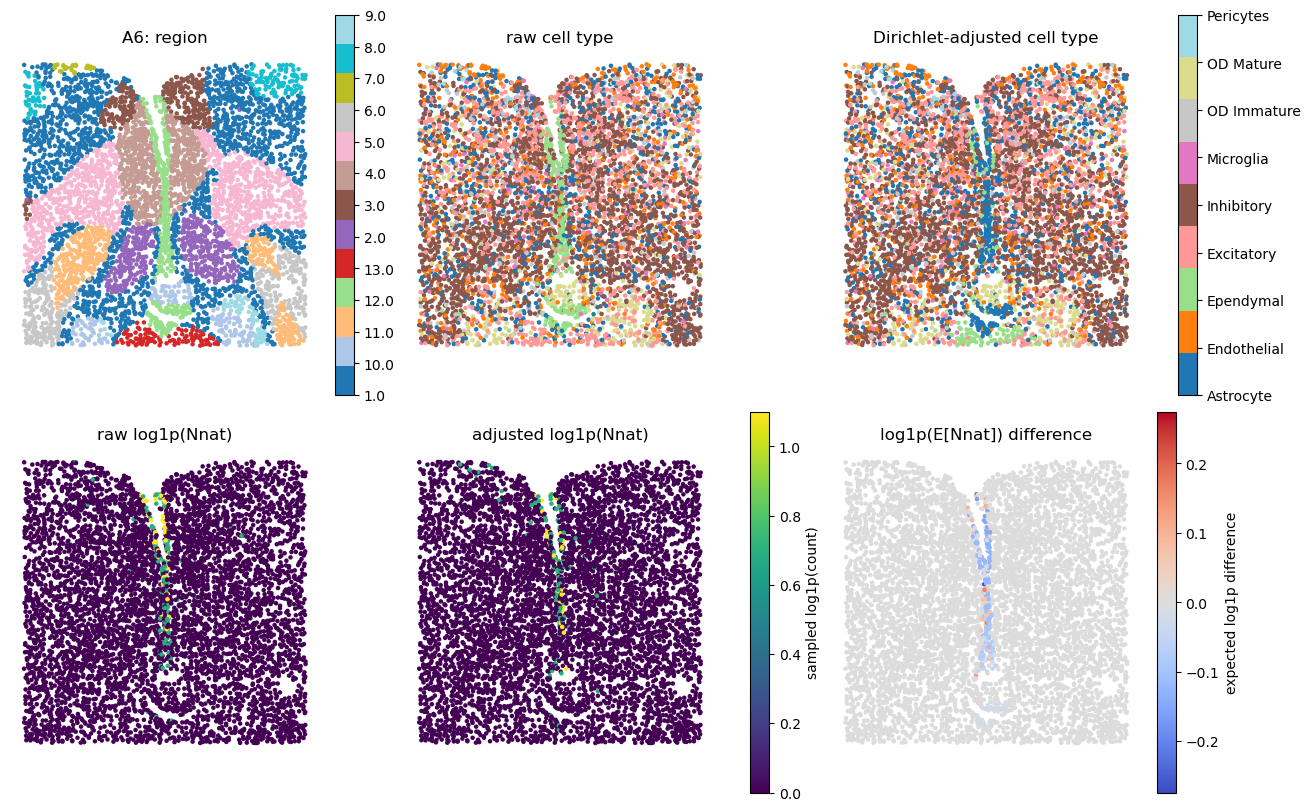

Saved to: /Users/yyq/Documents/MyDocuments/project/吴浩老师 3d ST simulator/code/20260525 志伟源代码+原始数据/code_add_info/All_slices_prediction_outputs/A6_dirichlet_celltype_intervention

Largest composition changes:
region  n_cells    celltype  raw_probability_mean  target_mean_before_dirichlet  dirichlet_target  adjusted_probability_mean  raw_sampled_proportion  adjusted_sampled_proportion  abs_probability_change
  12.0      344   Astrocyte              0.068202                      0.750000      7.419815e-01               7.419815e-01                0.043605                     0.767442                0.673779
  13.0      103   Ependymal              0.001673                      0.650000      6.605503e-01               6.605503e-01                0.000000                     0.679612                0.658878
  12.0      344   Ependymal              0.601102                      0.050000      5.413697e-02               5.413697e-02                0.633721                     0.043605           

In [7]:
obs = pd.DataFrame(
    {
        "batch": TARGET_SLICE,
        "x": xyz[:, 0],
        "y": xyz[:, 1],
        "z": xyz[:, 2],
        "size": library_size,
        "pred_region": regions,
        "raw_pred_celltype": raw_celltypes,
        "dirichlet_pred_celltype": adjusted_celltypes,
        f"expected_{PLOT_GENE}_raw": plot_mu_raw,
        f"expected_{PLOT_GENE}_dirichlet": plot_mu_adjusted,
    },
    index=[
        f"{TARGET_SLICE}_synthetic_{i}"
        for i in range(len(xyz))
    ],
)

synthetic = ad.AnnData(
    X=csr_matrix(counts_adjusted),
    obs=obs,
    var=adata[:, genes].var.copy(),
)

synthetic.layers["counts"] = synthetic.X.copy()
synthetic.layers["raw_celltype_no_intervention_counts"] = (
    csr_matrix(counts_raw)
)
synthetic.layers["dirichlet_celltype_intervention_counts"] = (
    csr_matrix(counts_adjusted)
)

synthetic.obsm["spatial"] = xyz[:, :2].copy()
synthetic.obsm["spatial_3d"] = xyz.copy()
synthetic.obsm["raw_pred_celltype_proba"] = (
    raw_celltype_probability.astype(np.float32)
)
synthetic.obsm["dirichlet_pred_celltype_proba"] = (
    adjusted_celltype_probability.astype(np.float32)
)
synthetic.uns["pred_celltype_names"] = celltype_names.astype(str)
synthetic.uns["dirichlet_kappa"] = DIRICHLET_KAPPA
synthetic.uns["manual_celltype_targets"] = MANUAL_CELLTYPE_TARGETS

synthetic.write_h5ad(
    OUT_DIR / f"{TARGET_SLICE}_dirichlet_celltype_intervention_v2.h5ad"
)

region_levels = sorted(pd.unique(regions))
cell_levels = sorted(
    set(pd.unique(raw_celltypes))
    | set(pd.unique(adjusted_celltypes))
)

plot_gene_index = genes.index(PLOT_GENE)

log_raw = np.log1p(counts_raw[:, plot_gene_index])
log_adjusted = np.log1p(counts_adjusted[:, plot_gene_index])
log_mu_diff = np.log1p(plot_mu_adjusted) - np.log1p(plot_mu_raw)

expression_vmax = max(
    float(np.percentile(np.r_[log_raw, log_adjusted], 99.5)),
    np.log1p(2),
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 8),
    constrained_layout=True,
)

region_scatter = axes[0, 0].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=pd.Categorical(
        regions,
        categories=region_levels,
    ).codes,
    s=5,
    cmap=ListedColormap(
        plt.cm.tab20(
            np.linspace(0, 1, len(region_levels))
        )
    ),
)

raw_cell_scatter = axes[0, 1].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=pd.Categorical(
        raw_celltypes,
        categories=cell_levels,
    ).codes,
    s=5,
    cmap=ListedColormap(
        plt.cm.tab20(
            np.linspace(0, 1, len(cell_levels))
        )
    ),
)

axes[0, 2].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=pd.Categorical(
        adjusted_celltypes,
        categories=cell_levels,
    ).codes,
    s=5,
    cmap=ListedColormap(
        plt.cm.tab20(
            np.linspace(0, 1, len(cell_levels))
        )
    ),
)

raw_expr_scatter = axes[1, 0].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=log_raw,
    s=5,
    cmap="viridis",
    vmin=0,
    vmax=expression_vmax,
)

axes[1, 1].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=log_adjusted,
    s=5,
    cmap="viridis",
    vmin=0,
    vmax=expression_vmax,
)

diff_abs = max(float(np.max(np.abs(log_mu_diff))), 1e-6)
diff_scatter = axes[1, 2].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=log_mu_diff,
    s=5,
    cmap="coolwarm",
    vmin=-diff_abs,
    vmax=diff_abs,
)

axes[0, 0].set_title(f"{TARGET_SLICE}: region")
axes[0, 1].set_title("raw cell type")
axes[0, 2].set_title("Dirichlet-adjusted cell type")
axes[1, 0].set_title(f"raw log1p({PLOT_GENE})")
axes[1, 1].set_title(f"adjusted log1p({PLOT_GENE})")
axes[1, 2].set_title(f"log1p(E[{PLOT_GENE}]) difference")

for axis in axes.ravel():
    axis.set_aspect("equal")
    axis.invert_yaxis()
    axis.axis("off")

region_bar = fig.colorbar(
    region_scatter,
    ax=axes[0, 0],
    ticks=np.arange(len(region_levels)),
)
region_bar.ax.set_yticklabels(region_levels)

cell_bar = fig.colorbar(
    raw_cell_scatter,
    ax=axes[0, 1:],
    ticks=np.arange(len(cell_levels)),
)
cell_bar.ax.set_yticklabels(cell_levels)

fig.colorbar(
    raw_expr_scatter,
    ax=axes[1, :2],
    label="sampled log1p(count)",
)
fig.colorbar(
    diff_scatter,
    ax=axes[1, 2],
    label="expected log1p difference",
)

plt.savefig(
    OUT_DIR / f"{TARGET_SLICE}_dirichlet_celltype_intervention_v2.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print("Saved to:", OUT_DIR.resolve())
print("\nLargest composition changes:")
print(
    composition_summary.assign(
        abs_probability_change=lambda x: np.abs(
            x["adjusted_probability_mean"]
            - x["raw_probability_mean"]
        )
    )
    .sort_values(
        "abs_probability_change",
        ascending=False,
    )
    .head(20)
    .to_string(index=False)
)

## Interpretation of the six panels of the figure

This figure compares the synthetic data generated without cell-type composition intervention and the synthetic data generated after adding the Dirichlet-adjusted cell-type intervention.

The six panels can be interpreted as follows.

### 1. Top-left: `A6: region`

This panel shows the simulated region labels for A6.

These labels are generated by the saved domain model:

$$
(x_i,y_i,z_i)
\rightarrow
R_i.
$$

Therefore, this panel is not a manually modified region map. It is the region map predicted by the domain MLP from the 3D spatial coordinates of A6.

More specifically, the saved domain model does not store a fixed region label for each cell. Instead, it stores the trained MLP parameters, the coordinate scaler, and the label encoder. For A6, the code first extracts the 3D coordinates from `adata.obsm["spatial_3d"]` and standardizes them using the saved scaler. The standardized coordinates are then passed into the domain MLP, which outputs one score for each of the 13 region classes.

The final region label is obtained by a deterministic hard assignment:

$$
\widehat{k}_i
=
\arg\max_k s_{ik},
$$

where $s_{ik}$ is the MLP score for cell $i$ and region class $k$. The predicted class index $\widehat{k}_i$ is then converted back to the original region label using the saved `label_encoder.inverse_transform()`.

Therefore, the A6 region panel is generated by prediction from the saved domain classifier, not by loading precomputed cell-level region labels from the model and not by sampling from a categorical distribution. With the same saved model and the same A6 coordinates, this step is deterministic.

---

### 2. Top-middle: `raw cell type`

This panel shows the cell-type labels generated without the Dirichlet composition intervention.

The generation process is:

$$
R_i,\ \text{relative coordinates}
\rightarrow
\boldsymbol p_i
=
(p_{i1},\ldots,p_{iC})
\rightarrow
C_i^{\mathrm{raw}}.
$$

Here, $\boldsymbol p_i$ is the original cell-type probability vector predicted by the cell-type MLP. The raw cell-type label is then sampled from this probability vector.

Thus, this panel represents the baseline synthetic cell-type map.

---

### 3. Top-right: `Dirichlet-adjusted cell type`

This panel shows the cell-type labels generated after applying the manually specified Dirichlet cell-type composition intervention.

For each specified region, such as regions `12.0` and `13.0`, the code first constructs a target composition vector:

$$
\boldsymbol m_r.
$$

Then it draws a Dirichlet random vector:

$$
\boldsymbol\pi_r
\sim
\operatorname{Dirichlet}
(
\kappa\boldsymbol m_r
).
$$

Next, the original cell-level probabilities $\boldsymbol p_i$ are calibrated into adjusted probabilities:

$$
\widetilde{\boldsymbol p}_i.
$$

Finally, the adjusted cell-type labels are sampled from the calibrated probabilities:

$$
C_i^{\mathrm{adj}}
\sim
\operatorname{Categorical}
(
\widetilde{\boldsymbol p}_i
).
$$

Therefore, this panel displays the simulated cell-type map after the artificial cell-type composition change.

In the figure, the colors in the central vertical structure and the bottom curved structure change visibly, indicating that the Dirichlet intervention has taken effect.

---

### 4. Bottom-left: `raw log1p(Nnat)`

This panel shows the simulated Nnat expression generated based on the raw cell-type labels.

First, the raw cell types are used to construct the gene-expression design matrix:

$$
X_i^{\mathrm{raw}}.
$$

Then the conditional mean is computed as:

$$
\log\mu_{ig}^{\mathrm{raw}}
=
\log L_i
+
X_i^{\mathrm{raw}\top}
\widehat\beta_g.
$$

The expression count is then sampled from a negative-binomial distribution:

$$
Y_{ig}^{\mathrm{raw}}
\sim
\operatorname{NB}
(
\mu_{ig}^{\mathrm{raw}},
\widehat\alpha_g
).
$$

The plotted value is:

$$
\log(1+Y_{i,\mathrm{Nnat}}^{\mathrm{raw}}).
$$

Therefore, this panel shows one sampled count realization, not the expected value.

---

### 5. Bottom-middle: `adjusted log1p(Nnat)`

This panel shows the simulated Nnat expression generated based on the Dirichlet-adjusted cell-type labels.

The corresponding conditional mean is:

$$
\log\mu_{ig}^{\mathrm{adj}}
=
\log L_i
+
X_i^{\mathrm{adj}\top}
\widehat\beta_g.
$$

Then the count is sampled as:

$$
Y_{ig}^{\mathrm{adj}}
\sim
\operatorname{NB}
(
\mu_{ig}^{\mathrm{adj}},
\widehat\alpha_g
).
$$

The plotted value is:

$$
\log(1+Y_{i,\mathrm{Nnat}}^{\mathrm{adj}}).
$$

The difference between this panel and the bottom-left panel mainly comes from the cell-type composition change. If Nnat is associated with certain cell types, changing the proportions of those cell types will naturally change the spatial expression pattern of Nnat.

However, because this panel shows sampled counts, it also contains negative-binomial sampling noise.

---

### 6. Bottom-right: `log1p(E[Nnat]) difference`

This is the most direct effect map. It does not show sampled counts. Instead, it shows the difference in expected expression:

$$
\log(1+\mu_{i,\mathrm{Nnat}}^{\mathrm{adj}})
-
\log(1+\mu_{i,\mathrm{Nnat}}^{\mathrm{raw}}).
$$

The colors can be interpreted as follows:

- red: the expected Nnat expression increases after the Dirichlet intervention;
- blue: the expected Nnat expression decreases after the Dirichlet intervention;
- gray: the expected Nnat expression is almost unchanged.

Because this panel is based on expected values, it removes the negative-binomial sampling noise and more directly reflects the effect of:

$$
\text{cell-type composition intervention}
\rightarrow
\text{gene-expression mean change}.
$$

In this figure, the changes are mainly concentrated around the central structure, suggesting that the Dirichlet intervention primarily changes the cell-type composition in those regions and that the expected Nnat expression is affected mainly there.

---

## Overall interpretation

The six panels form the following simulation chain:

$$
\boxed{
\text{region map}
\rightarrow
\text{raw cell-type map}
\rightarrow
\text{Dirichlet-adjusted cell-type map}
\rightarrow
\text{raw Nnat expression}
\rightarrow
\text{adjusted Nnat expression}
\rightarrow
\text{expected expression difference}
}
$$

The first row verifies whether the cell-type composition intervention changes the cell-type map. The second row shows whether this cell-type change further propagates to marker-gene expression.

The bottom-right panel is the cleanest effect map because it compares expected expression rather than one noisy sampled count realization.